# Практика. Тензорное исчисление и автоматическое дифференцирование
---

## Цели работы
1. Научиться создавать и преобразовывать тензоры в PyTorch.
2. Понять механизм broadcasting и выполнять базовые линейно-алгебраические операции.
3. Вычислить градиент простой функции аналитически и сравнить с результатом `autograd`.
4. Исследовать вычислительный граф на примере более сложной функции.

---

## Повторение (на пальцах 🖐️)

- **Тензор** — это просто многомерный массив. Скаляр (0D), вектор (1D), матрица (2D), кубик (3D) и дальше — сколько угодно измерений.
- **Broadcasting** — умное растягивание меньшего тензора под размер большего при выполнении операций (как когда вы на вечеринке растягиваете историю, чтобы её слушали все).
- **Градиент** — вектор частных производных. Показывает направление наискорейшего роста функции. В машинном обучении мы идём **против** градиента, чтобы уменьшить ошибку.
- **Autograd** — встроенный в PyTorch механизм автоматического дифференцирования. Он строит вычислительный граф и по команде `.backward()` раскручивает его в обратную сторону, заполняя градиенты.

Всё вспомнили? Поехали!

## Задание 1. Основы тензорных операций

**Цель:** освоиться с созданием, индексацией, broadcasting и линейной алгеброй в PyTorch.

Импортируйте PyTorch (и NumPy, если потребуется) и выполните следующие пункты. Пишите код в ячейках ниже.

1. Создайте:
   - скаляр со значением 3.14;
   - вектор из чисел от 0 до 99;
   - матрицу 3×3, заполненную единицами;
   - тензор размера 2×3×4, заполненный случайными числами из стандартного нормального распределения (используйте `torch.randn`).
2. Создайте две случайные матрицы 5×5 и сложите их поэлементно.
3. Создайте матрицу 3×4 и вектор длины 4. Выполните матричное умножение (используйте `@` или `torch.mm`). Что получилось? Какой размер у результата?
4. Создайте вектор `v = torch.tensor([1, 2, 3])` и матрицу `m = torch.tensor([[[10, 20, 30], [40, 50, 60]],[[10, 20, 30], [40, 50, 60]]])`. Сложите их (`v + m`). Объясните, как сработал broadcasting.
5. Создайте тензор формы (1, 24). Измените его форму на (3, 8) с помощью `.view()`. Что произойдёт, если вы попытаетесь изменить на (2, 13)? Проверьте и зафиксируйте ошибку.

*Подсказка:* размерности можно проверять через `.shape`.

**Выводы по заданию 1:** (напишите в Markdown-ячейке после кода)

In [20]:
# Ваш код для задания 1
import torch

# 1. Создание тензоров
scalar = torch.tensor(3.14)
vector = torch.arange(0, 100)
matrix_ones = torch.ones([3, 3])
tensor_randn = torch.randn([2, 3, 4])
print(scalar)
print(vector)
print(matrix_ones)
print(tensor_randn, tensor_randn.shape)

# 2. Случайные матрицы и сложение
A = torch.randn([5, 5])
B = torch.randn([5, 5])
C = A + B

# 3. Матричное умножение
M = torch.randn(3,4)
v = torch.randn(4)
result = M @ v
print(result.shape)

# 4. Broadcasting
v = torch.tensor([1,2,3])
m = torch.tensor([[10,20,30],[40,50,60]])
sum_bc = v + m
print(sum_bc)

# 5. Изменение формы
x = torch.randn(1,24)
x_reshaped = x.view(3, 8)
print(x_reshaped.shape)
try:
  x.view(2,13)
except Exception as e:
  print(e)

tensor(3.1400)
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
        36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53,
        54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71,
        72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89,
        90, 91, 92, 93, 94, 95, 96, 97, 98, 99])
tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])
tensor([[[ 1.2144,  1.1315,  0.6671, -0.4673],
         [-0.3367, -1.4400,  0.6686,  1.7292],
         [-1.5451, -1.5311, -0.3595, -0.5648]],

        [[ 0.0208,  0.2044, -0.6440, -1.5268],
         [ 0.1626,  1.2341,  0.9665, -1.2463],
         [ 0.5520,  1.6991, -0.3785, -0.1196]]]) torch.Size([2, 3, 4])
torch.Size([3])
tensor([[11, 22, 33],
        [41, 52, 63]])
torch.Size([3, 8])
shape '[2, 13]' is invalid for input of size 24


### Место для выводов по заданию 1
Тензоры всех требуемых форм были созданы, операции матричного сложения и умножения дали ожидаемые результаты.<br>Broadcasting сработал за счёт автоматического расширения вектора по недостающим осям матрицы/тензора.<br>При попытке x.view(2, 13) возникла ошибка: "shape '[2, 13]' is invalid for input of size 24", потому что число элементов - 24 не совпадает с новой формой - 2 * 13 = 26.

## Задание 2. Ручной расчёт градиента и проверка autograd

**Цель:** убедиться, что autograd не врёт, и заодно вспомнить частные производные.

Рассмотрим функцию двух переменных (сразу смотрите функцию из бонусного варианта):
$$
f(x, y) = x^2 y + y^3
$$

1. Аналитически найдите частные производные и вычислите градиент в точке $x = 2, y = 3$. Запишите ответы (можно прямо в Markdown).
2. Создайте тензоры `x` и `y` с `requires_grad=True`, инициализировав их значениями 2 и 3.
3. Вычислите `f` и вызовите `backward()`.
4. Распечатайте `x.grad` и `y.grad`. Сравните с аналитическим расчётом.
5. **Бонус:** измените функцию, например, добавьте синус: $f = x^2 y + \sin(y)$. Повторите вычисления аналитически и через autograd.

*Подсказка:* аналитически: $\partial f/\partial x = 2xy$, $\partial f/\partial y = x^2 + 3y^2$. При (2,3): (12, 4+27=31).

In [21]:
# Ваш код для задания 2
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)

f = x**2 * y + y**3
f.backward()

print("Градиент по x:", x.grad)
print("Градиент по y:", y.grad)

# Бонус: f = x^2 * y + sin(y)
x2 = torch.tensor(2.0, requires_grad=True)
y2 = torch.tensor(3.0, requires_grad=True)
f_bonus = x2**2 * y2 + torch.sin(y2)
f_bonus.backward()

print("Градиент по x:", x2.grad)
print("Градиент по y:", y2.grad)

Градиент по x: tensor(12.)
Градиент по y: tensor(31.)
Градиент по x: tensor(12.)
Градиент по y: tensor(3.0100)


### Выводы по заданию 2
Градиенты совпали с аналитическими значениями.<br>Для основной функции получились 12 и 31.<br>Следовательно автоматическое дифференцирование в PyTorch работает корректно.

## Задание 3. Исследование вычислительного графа

**Цель:** научиться отслеживать промежуточные узлы графа и понимать, откуда берутся градиенты.

Дана функция:
$$
L = (\mathbf{a} \cdot \mathbf{b} + c)^2
$$
где $\mathbf{a}, \mathbf{b}$ — векторы длины 3, $c$ — скаляр, а $\cdot$ — скалярное произведение (можно использовать `torch.dot`).

1. Задайте конкретные значения: `a = torch.tensor([1., 2., 3.], requires_grad=True)`, `b = torch.tensor([4., 5., 6.], requires_grad=True)`, `c = torch.tensor([7.], requires_grad=True)`.
2. Вычислите `L`.
3. Вызовите `backward()` и выведите градиенты по `a`, `b`, `c`.
4. Попробуйте объяснить, почему градиент по `a` именно такой. Для этого можно:
   - Вспомнить, что скалярное произведение — это сумма поэлементных произведений.
   - Записать формулу явно и взять производную по каждому компоненту.
5. (Бонус) Выведите значение промежуточного узла: `s = torch.dot(a, b) + c` и его градиент (можно получить, если сохранить его и вызвать ` s.retain_grad()  s.backward()`, но аккуратно с повторным вызовом).

**Важно:** перед повторным вызовом backward нужно обнулить градиенты, иначе они накопятся. Используйте `.zero_()`.

In [22]:
# Ваш код для задания 3
a = torch.tensor([1., 2., 3.], requires_grad=True)
b = torch.tensor([4., 5., 6.], requires_grad=True)
c = torch.tensor([7.], requires_grad=True)

s = torch.dot(a, b) + c
s.retain_grad()
L = s ** 2
L.backward()

print("s:", s.item())
print("grad a:", a.grad)
print("grad b:", b.grad)
print("grad c:", c.grad)
print("grad s:", s.grad)

# Проверка формул: dL/da = 2*s*b, dL/db = 2*s*a, dL/dc = 2*s
with torch.no_grad():
    expected_grad_a = 2 * s * b
    expected_grad_b = 2 * s * a
    expected_grad_c = 2 * s

print("Ожидаемый grad a:", expected_grad_a)
print("Ожидаемый grad b:", expected_grad_b)
print("Ожидаемый grad c:", expected_grad_c)

s: 39.0
grad a: tensor([312., 390., 468.])
grad b: tensor([ 78., 156., 234.])
grad c: tensor([78.])
grad s: tensor([78.])
Ожидаемый grad a: tensor([312., 390., 468.])
Ожидаемый grad b: tensor([ 78., 156., 234.])
Ожидаемый grad c: tensor([78.])


### Выводы по заданию 3
Градиенты соответствуют структуре функции: сначала считается скаляр s = a·b + c, а затем из-за квадрата появляется множитель 2s. Поэтому grad a пропорционален b, grad b пропорционален a, а grad c = 2s. Промежуточный узел s помогает наглядно увидеть применение правила цепочки.

## Задание 4. Линейная регрессия с autograd

**Цель:** применить autograd для обучения простой модели.

Сгенерируйте данные:
$$y_{\text{true}} = -5 x + 12 + \text{шум}$$
для 200 точек x от -10 до 10.

Инициализируйте случайные параметры `w` и `b` с `requires_grad=True`. Напишите цикл обучения на 100 эпох:
- оценка целевой функции `y_pred = w * x + b`;
- функция потерь: RMSE (`((y_pred - y_true)**2).mean()`) (добавить корень);
- `loss.backward()`;
- обновление весов вручную (без оптимизатора): `w.data -= lr * w.grad`, `b.data -= lr * b.grad` (используйте `.data` или блок `torch.no_grad()`);
- обнуление градиентов.

Выведите итоговые параметры и постройте
1. График изменения loss с увеличением эпох;
2. Линейные графики исходной и полученной функций;
3. График самой функции loss и движение поиска минимума по ней.

*Подсказка:* не забудьте обнулять градиенты после каждого шага.

Это задание повторяет пример из лекции — попробуйте выполнить его без подглядывания, а потом сверьтесь.

Результат: w = -5.017, b = 12.061


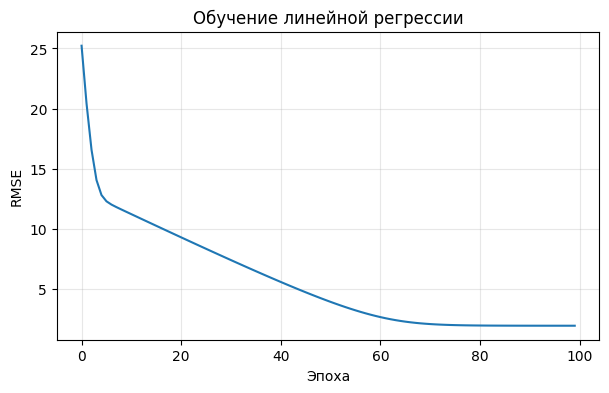

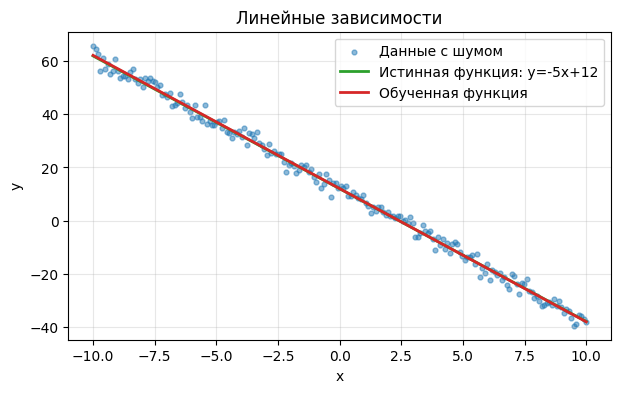

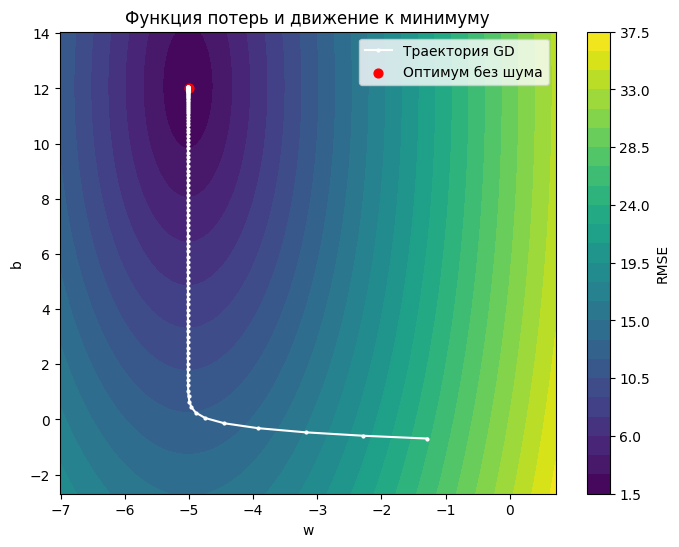

In [23]:
# Ваш код для задания 4
import matplotlib.pyplot as plt

torch.manual_seed(42)

# Генерация данных
x_true = torch.linspace(-10, 10, 200)
y_line = -5 * x_true + 12
y_true = y_line + torch.randn_like(x_true) * 2.0

# Инициализация параметров
w = torch.randn(1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

lr = 0.2
epochs = 100
loss_history = []
w_history = []
b_history = []

for epoch in range(epochs):
    # Прямой проход
    y_pred = w * x_true + b
    loss = torch.sqrt(((y_pred - y_true) ** 2).mean())
    loss_history.append(loss.item())
    w_history.append(w.item())
    b_history.append(b.item())

    # Обратный проход
    loss.backward()

    # Обновление весов
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad

    # Обнуление градиентов
    w.grad.zero_()
    b.grad.zero_()

print(f"Результат: w = {w.item():.3f}, b = {b.item():.3f}")

# 1. График изменения loss по эпохам
plt.figure(figsize=(7, 4))
plt.plot(loss_history, color="tab:blue")
plt.xlabel("Эпоха")
plt.ylabel("RMSE")
plt.title("Обучение линейной регрессии")
plt.grid(alpha=0.3)
plt.show()

# 2. Сравнение исходной и полученной функций
with torch.no_grad():
    y_fit = w * x_true + b

plt.figure(figsize=(7, 4))
plt.scatter(x_true.numpy(), y_true.numpy(), s=12, alpha=0.5, label="Данные с шумом")
plt.plot(x_true.numpy(), y_line.numpy(), color="tab:green", linewidth=2, label="Истинная функция: y=-5x+12")
plt.plot(x_true.numpy(), y_fit.numpy(), color="tab:red", linewidth=2, label="Обученная функция")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Линейные зависимости")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 3. Ландшафт функции loss и траектория поиска минимума
w_min = min(min(w_history), -5.0) - 2
w_max = max(max(w_history), -5.0) + 2
b_min = min(min(b_history), 12.0) - 2
b_max = max(max(b_history), 12.0) + 2

w_vals = torch.linspace(w_min, w_max, 120)
b_vals = torch.linspace(b_min, b_max, 120)
W, B = torch.meshgrid(w_vals, b_vals, indexing="ij")

X = x_true.view(1, 1, -1)
Y = y_true.view(1, 1, -1)
pred_grid = W.unsqueeze(-1) * X + B.unsqueeze(-1)
loss_grid = torch.sqrt(((pred_grid - Y) ** 2).mean(dim=-1))

plt.figure(figsize=(8, 6))
contour = plt.contourf(W.numpy(), B.numpy(), loss_grid.numpy(), levels=30, cmap="viridis")
plt.colorbar(contour, label="RMSE")
plt.plot(w_history, b_history, color="white", linewidth=1.5, marker="o", markersize=2, label="Траектория GD")
plt.scatter([-5], [12], color="red", s=40, label="Оптимум без шума")
plt.xlabel("w")
plt.ylabel("b")
plt.title("Функция потерь и движение к минимуму")
plt.legend()
plt.show()

### Выводы по заданию 4
Модель успешно обучилась: значения w и b приблизились к параметрам исходной зависимости. RMSE по эпохам стабильно уменьшался, что показывает корректную работу градиентного спуска. По траектории на графике функции потерь видно, как параметры двигались в область минимума.

## Заключение

Поздравляю, вы пережили первое практическое занятие! Теперь вы умеете:
- создавать тензоры любой размерности;
- использовать broadcasting;
- считать градиенты вручную и доверять autograd;
- строить простые вычислительные графы.

Эти навыки пригодятся уже на следующем занятии, когда мы будем визуализировать градиентный спуск. Если остались вопросы — не стесняйтесь задавать (и да, чат с одногруппниками тоже работает).

**Сдавайте выполненную работу в виде этого блокнота с заполненными ячейками и выводами.**

Успехов!